# Разработка A/B-тестирования и анализ результатов

**Контекст:** Вы работаете продуктовым аналитиком в компании, которая разрабатывает развлекательное приложение с функцией «бесконечной» ленты, как, например, в приложениях с короткими видео. В вашем приложении существует две модели монетизации: первая — ежемесячная платная подписка, которая позволяет пользователям смотреть ленту без рекламы, вторая — демонстрация рекламы для пользователей, которые ещё не оформили подписку.

Команда разработчиков рекомендательных систем создала новый алгоритм рекомендаций, который, по их мнению, будет показывать более интересный контент для каждого пользователя. Вас, как аналитика, просят помочь рассчитать параметры A/B-теста, который позволит проверить эту гипотезу, и проанализировать его результаты.

- Автор: Мельников Даниил
- Дата: 17.04.2026 г.

# Содержание  
[1. Описание данных](#описание-данных)  
[2. Цели и задачи](#цели-и-задачи)  
[3. Работа с историческими данными (EDA)](#работа-с-историческими-данными-(EDA))  
&nbsp;&nbsp;[3.1. Загрузка исторических данных](#загрузка-исторических-данных)  
&nbsp;&nbsp;[3.2. Знакомство с данными](#знакомство-с-данными)  
&nbsp;&nbsp;[3.3. Анализ числа регистраций](#анализ-числа-регистраций)  
&nbsp;&nbsp;[3.4. Анализ числа просмотренных страниц](#анализ-числа-просмотренных-страниц)  
&nbsp;&nbsp;[3.5. Доля пользователей, просмотревших более четырёх страниц](#доля-пользователей,-просмотревших-более-четырёх-страниц)  
[4. Подготовка к тесту](#подготовка-к-тесту)  
&nbsp;&nbsp;[4.1. Расчёт размера выборки](#расчёт-размера-выборки)  
&nbsp;&nbsp;[4.2. Расчёт длительности A/B-теста](#расчёт-длительности-A/B-теста)  
[5. Мониторинг А/В-теста](#мониторинг-А/В-теста)  
&nbsp;&nbsp;[5.1. Проверка распределения пользователей](#проверка-распределения-пользователей)  
&nbsp;&nbsp;[5.2. Проверка пересечений пользователей](#проверка-пересечений-пользователей)  
&nbsp;&nbsp;[5.3. Равномерность разделения пользователей по устройствам](#равномерность-разделения-пользователей-по-устройствам)  
&nbsp;&nbsp;[5.4. Равномерность распределения пользователей по регионам](#равномерность-распределения-пользователей-по-регионам)  
с[5.5. Вывод после проверки A/B-теста](#вывод-после-проверки-A/B-теста)  
[6. Проверка результатов A/B-теста](#проверка-результатов-A/B-теста)  
&nbsp;&nbsp;[6.1. Получение результатов теста и подсчёт основной метрики](#получение-результатов-теста-и-подсчёт-основной-метрики)  
&nbsp;&nbsp;[6.2. Формулировка нулевой и альтернативной гипотез. Определение целевой, прокси- и барьерных метрик](#формулировка-нулевой-и-альтернативной-гипотез.-Определение-целевой,-прокси--и-барьерных-метрик)  
&nbsp;&nbsp;[6.3. Сравнение доли успешных первых сессий](#сравнение-доли-успешных-первых-сессий)  
&nbsp;&nbsp;[6.4. Насколько статистически значимо изменение ключевой метрики](#насколько-статистически-значимо-изменение-ключевой-метрики)  
&nbsp;&nbsp;[6.5. Вывод по результатам A/B-эксперимента](#вывод-по-результатам-A/B-эксперимента)

## Описание данных

Используемые таблицы:

- `sessions_project_history.csv` — таблица с историческими данными по сессиям пользователей на период с 2025-08-15 по 2025-09-23.

- `sessions_project_test_part.csv` — таблица с данными за первый день проведения A/B-теста, то есть за 2025-10-14.

- `sessions_project_test.csv` — таблица с данными за весь период проведения A/B-теста, то есть с 2025-10-14 по 2025-11-02.


Поля таблиц `sessions_project_history.csv`, `sessions_project_test.csv`, `sessions_project_test_part.csv`:

- `user_id` — идентификатор пользователя;

- `session_id` — идентификатор сессии в приложении;

- `session_date` — дата сессии;

- `session_start_ts` — дата и время начала сессии;

- `install_date` — дата установки приложения;

- `session_number` — порядковый номер сессии для конкретного пользователя;

- `registration_flag` — является ли пользователь зарегистрированным;

- `page_counter` — количество просмотренных страниц во время сессии;

- `region` — регион пользователя;

- `device` — тип устройства пользователя;

- `test_group` — тестовая группа (в таблице с историческими данными этого столбца нет).

## Цели и задачи
Рассчитать параметры теста, оценить корректность его проведения и проанализировать результаты эксперимента.

## Работа с историческими данными (EDA)

### Загрузка исторических данных

In [18]:
#В данной ячейке импортируем все необходимые библиотеки
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
from math import ceil
from statsmodels.stats.proportion import proportions_ztest

In [2]:
sessions_history = pd.read_csv('/datasets/sessions_project_history.csv')

sessions_history.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android


### Знакомство с данными
- Для каждого уникального пользователя `user_id` рассчитаем количество уникальных сессий `session_id`.

- Выводим на экран все данные из таблицы `sessions_history` для одного пользователя с наибольшим количеством сессий.

- Изучим таблицу для одного пользователя, чтобы лучше понять логику формирования каждого столбца данных.

In [3]:
# Считаем кол-во сессий для каждого пользователя
sessions_count = sessions_history.groupby('user_id')['session_id'].nunique().sort_values(ascending=False)

# Отображаем таблицу для топ-пользователя
top_user_data = sessions_history[sessions_history['user_id'] == '10E0DEFC1ABDBBE0']

display(sessions_count)
top_user_data

user_id
10E0DEFC1ABDBBE0    10
6A73CB5566BB494D    10
D11541BAC141FB94     9
E8ADFF2913E86056     9
FA752AB58040C361     9
                    ..
29643A4DF88AF0CD     1
297264C724CBB558     1
296E7BCDA4004B88     1
296C03E6A6014B36     1
B42D1E6D93C2DCE5     1
Name: session_id, Length: 134039, dtype: int64

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
115558,10E0DEFC1ABDBBE0,B8F0423BBFFCF5DC,2025-08-14,2025-08-14 13:57:39,2025-08-14,1,0,4,CIS,Android
191751,10E0DEFC1ABDBBE0,87CA2FA549473837,2025-08-15,2025-08-15 16:42:10,2025-08-14,2,0,3,CIS,Android
239370,10E0DEFC1ABDBBE0,4ADD8011DCDCE318,2025-08-16,2025-08-16 19:53:21,2025-08-14,3,0,3,CIS,Android
274629,10E0DEFC1ABDBBE0,DF0FD0E09BF1F3D7,2025-08-17,2025-08-17 15:03:43,2025-08-14,4,0,1,CIS,Android
302501,10E0DEFC1ABDBBE0,3C221774B4DE6885,2025-08-18,2025-08-18 17:29:14,2025-08-14,5,0,4,CIS,Android
325557,10E0DEFC1ABDBBE0,031BD7A67048105B,2025-08-19,2025-08-19 13:23:55,2025-08-14,6,0,2,CIS,Android
345336,10E0DEFC1ABDBBE0,FF4315CF4AD4B100,2025-08-20,2025-08-20 19:31:54,2025-08-14,7,0,2,CIS,Android
377532,10E0DEFC1ABDBBE0,4045FEA0747203B4,2025-08-22,2025-08-22 17:54:13,2025-08-14,8,0,2,CIS,Android
403538,10E0DEFC1ABDBBE0,344B086C421C7F37,2025-08-24,2025-08-24 14:46:13,2025-08-14,9,0,2,CIS,Android
414743,10E0DEFC1ABDBBE0,054F20BA371E4C9D,2025-08-25,2025-08-25 18:36:41,2025-08-14,10,0,3,CIS,Android


### Анализ числа регистраций
Одна из важнейших метрик продукта — число зарегистрированных пользователей. Используя исторические данные, визуализируем, как менялось число регистраций в приложении за время его существования. Пользователь считается зарегистрированным только в день совершения регистрации. Таким образом, необходимо проанализировать количество зарегистрированных активных пользователей за каждый день без накопления (аналог DAU, но для регистраций пользователей).

- Агрегируем исторические данные и рассчитываем число уникальных пользователей и число зарегистрированных пользователей для каждого дня наблюдения. Для простоты считаем, что у пользователя в течение дня бывает одна сессия максимум и статус регистрации в течение одного дня не может измениться.

- Построим линейные графики общего числа пользователей и общего числа зарегистрированных пользователей по дням.

- Построим отдельный линейный график доли зарегистрированных пользователей от всех пользователей по дням.

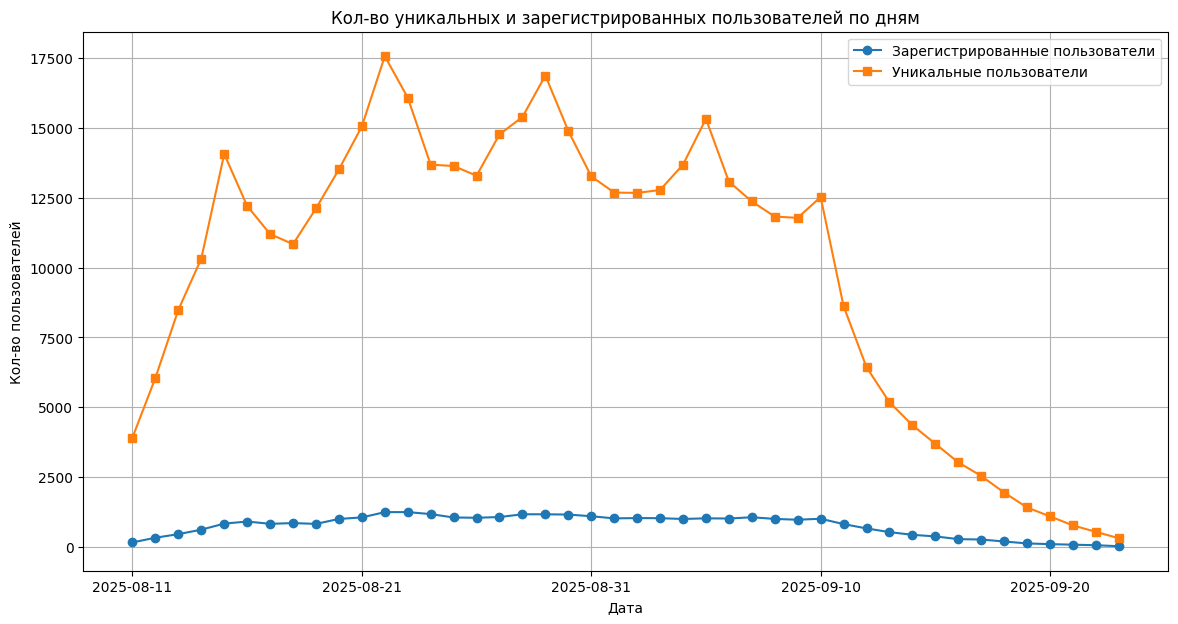

In [4]:
# Находим кол-во регистраций по дням
daily_reg = sessions_history[sessions_history['registration_flag'] == 1].groupby('session_date')['user_id'].nunique()

# Находим кол-во уникальных пользователей по дням
daily_unique_users = sessions_history.groupby('session_date')['user_id'].nunique()

# Строим график
plt.figure(figsize=(14, 7))

daily_reg.plot(kind='line', marker='o', label='Зарегистрированные пользователи')
daily_unique_users.plot(kind='line', marker='s', label='Уникальные пользователи')

plt.title('Кол-во уникальных и зарегистрированных пользователей по дням')
plt.xlabel('Дата')
plt.ylabel('Кол-во пользователей')
plt.legend()
plt.grid()
plt.show()

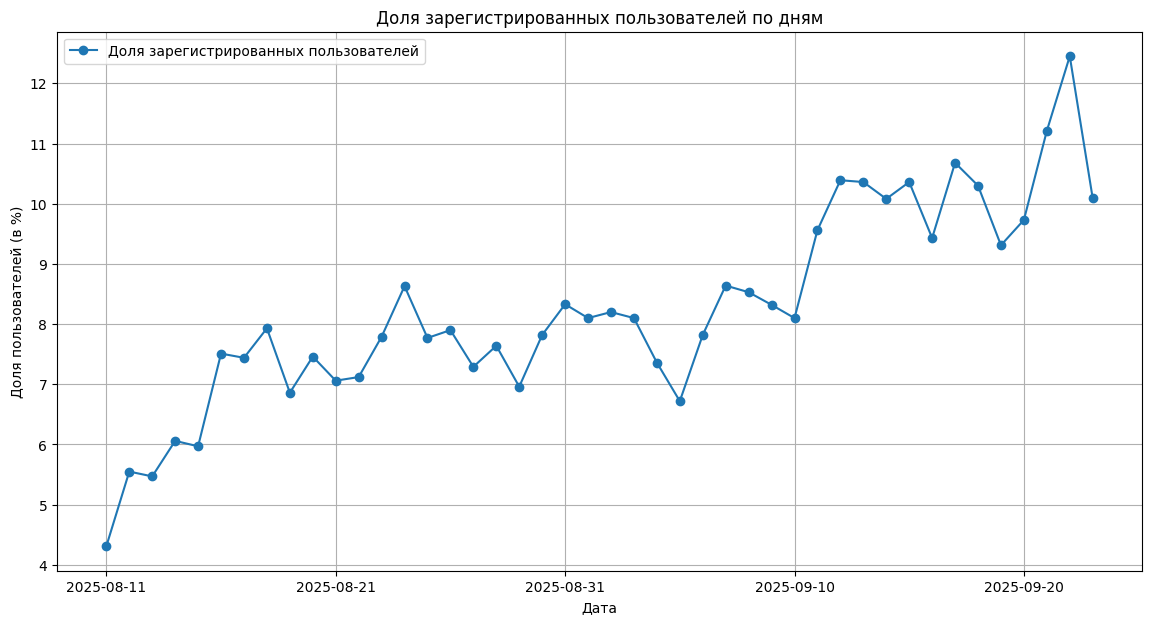

In [5]:
# Находим долю зарегистрированных пользователей
reg_percentage = round((daily_reg / daily_unique_users) * 100, 2)

#Строим график
plt.figure(figsize=(14, 7))
reg_percentage.plot(kind='line', marker='o', label='Доля зарегистрированных пользователей')
plt.title('Доля зарегистрированных пользователей по дням')
plt.xlabel('Дата')
plt.ylabel('Доля пользователей (в %)')
plt.legend()
plt.grid()
plt.show()

### Анализ числа просмотренных страниц
Другая важная метрика продукта — число просмотренных страниц в приложении. Чем больше страниц просмотрено, тем сильнее пользователь увлечён контентом, а значит, выше шансы, что он зарегистрируется и оплатит подписку.

Проанализируем число просмотренных страниц во время первых сессий пользователей. Найдем количество первых сессий для каждого значения количества просмотренных страниц.

- Построим столбчатую диаграмму, где по оси X будет число просмотренных страниц, по оси Y — количество сессий.

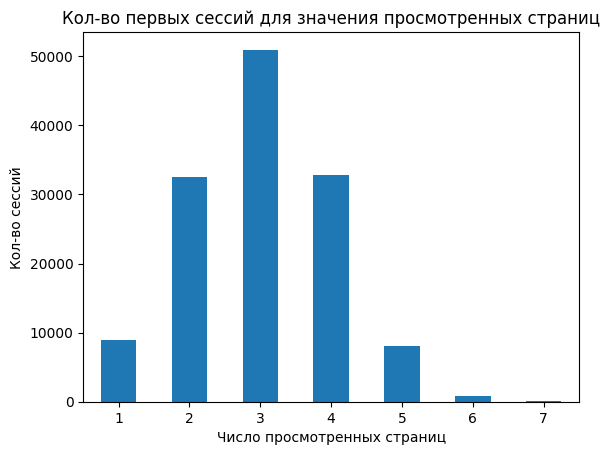

In [6]:
# Находим первыее сессии
first_sessions = sessions_history.groupby('user_id')['session_date'].min()

# Сопоставляем первые сессии с кол-вом просмотренных страниц
first_sessions_data = sessions_history.merge(first_sessions.reset_index(), on=['user_id','session_date'])
page_counter_in_first_sessions = first_sessions_data['page_counter'].value_counts().sort_index()

#Строим график
page_counter_in_first_sessions.plot(kind='bar', rot=0)
plt.title('Кол-во первых сессий для значения просмотренных страниц')
plt.xlabel('Число просмотренных страниц')
plt.ylabel('Кол-во сессий')
plt.show()

Во время первых сессий пользователи в большинстве случаев просматривают от 2 до 4 страниц. Наиболее часто - 3 страницы.

### Доля пользователей, просмотревших более четырёх страниц
Продуктовая команда продукта считает, что первые сессии, в рамках которых пользователь просмотрел 4 и более страниц, говорят об удовлетворённости контентом и алгоритмами рекомендаций. Этот показатель является важной прокси-метрикой для продукта.

- В датафрейме `sessions_history` создаем дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если было просмотрено меньше.

- Построим график со средним значением доли успешных первых сессий от всех первых сессий пользователей.

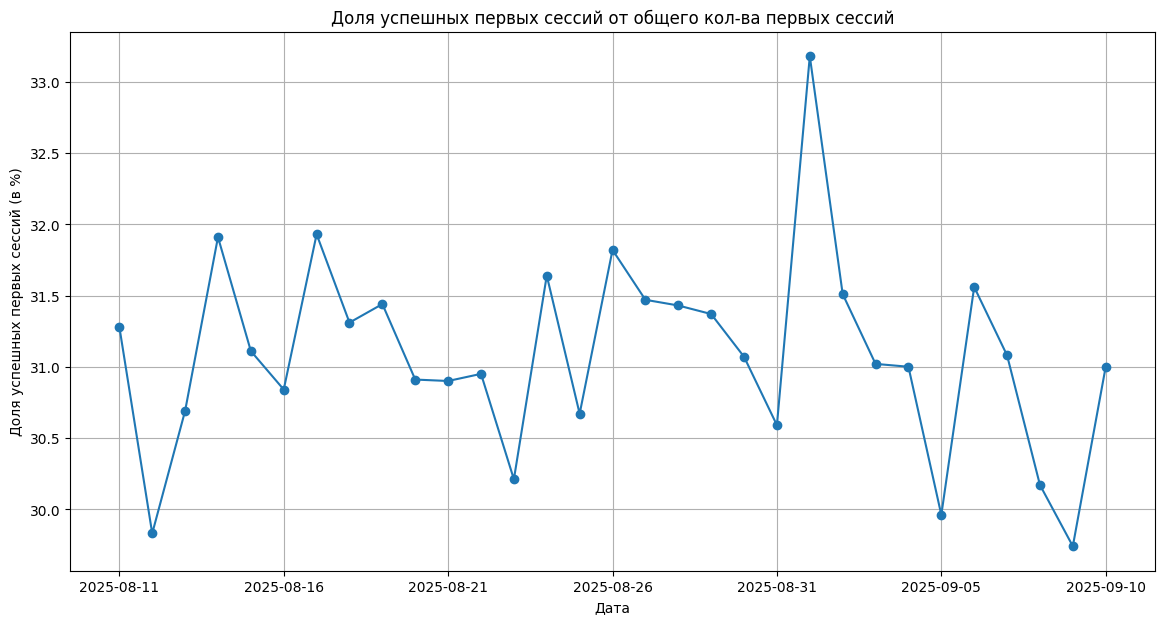

In [7]:
# Создаем пользовательску функцию для определения успешных первых сессий
def more_than_four_sessions(row):
    if row['page_counter'] >= 4:
        return 1
    else:
        return 0

# Создаем булевой столбец с успешными сессиями
first_sessions_data['good_session'] = first_sessions_data.apply(more_than_four_sessions, axis=1)
sessions_history['good_session'] = 0
sessions_history.loc[first_sessions_data.index, 'good_session'] = first_sessions_data['good_session']

# Находим долю успешных первых сессий
good_session_percentage = (first_sessions_data.groupby('session_date')['good_session'].mean() * 100).round(2)

# Строим график
plt.figure(figsize=(14, 7))
good_session_percentage.plot(kind='line', marker='o')
plt.title('Доля успешных первых сессий от общего кол-ва первых сессий')
plt.xlabel('Дата')
plt.ylabel('Доля успешных первых сессий (в %)')
plt.grid()
plt.show()

В среднем доли успешных первых сессий по дням держатся на уровне 30-32%.

## Подготовка к тесту
При планировании теста необходимо проделать несколько важных шагов:

- Определиться с целевой метрикой.

- Рассчитать необходимый размер выборки.

- Исходя из текущих значений трафика рассчитать необходимую длительность проведения теста.

### Расчёт размера выборки

In [8]:
# Задаем параметры:
alpha = 0.05  # Уровень значимости
beta = 0.2  # Ошибка второго рода, часто 1 - мощность
power = 0.8  # Мощность теста
p = 0.3 # Базовый уровень доли
mde = 0.009  # Минимальный детектируемый эффект
effect_size = proportion_effectsize(p, p + mde)

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Расчёт размера выборки
sample_size = power_analysis.solve_power(
    effect_size = effect_size,
    power = power,
    alpha = alpha,
    ratio = 1 # Равномерное распределение выборок
)

print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")

Необходимый размер выборки для каждой группы: 41040


### Расчёт длительности A/B-теста

In [9]:
# Среднее количество пользователей приложения в день по историческим данным
avg_daily_users = sessions_history.groupby('session_date')['user_id'].nunique().mean()

# Рассчитываем длительность теста в днях как отношение размера выборки к среднему числу пользователей
test_duration = ceil(sample_size * 2 / avg_daily_users)

print(f"Рассчитанная длительность A/B-теста при текущем уровене трафика в {avg_daily_users} пользователей в день составит {test_duration} дней")

Рассчитанная длительность A/B-теста при текущем уровене трафика в 9907.363636363636 пользователей в день составит 9 дней


## Мониторинг А/В-теста

### Проверка распределения пользователей

In [10]:
sessions_test_part = pd.read_csv('/datasets/sessions_project_test_part.csv')

# Считаем кол-во пользователей в группах
unique_users_a = sessions_test_part[sessions_test_part['test_group'] == 'A']['user_id'].nunique()
unique_users_b = sessions_test_part[sessions_test_part['test_group'] == 'B']['user_id'].nunique()

print(f'Группа А: {unique_users_a}')
print(f'Группа B: {unique_users_b}')

# Рассчитываем процентную разницу
percentage_diff = 100 * (unique_users_a - unique_users_b) / unique_users_a
print(f'Процентная разница: {percentage_diff}')

Группа А: 1477
Группа B: 1466
Процентная разница: 0.7447528774542993


### Проверка пересечений пользователей

In [11]:
# Првоеряем пересечение пользователей в группах
group_a = sessions_test_part[sessions_test_part['test_group'] == 'A']['user_id']
group_b = sessions_test_part[sessions_test_part['test_group'] == 'B']['user_id']

intersection = list(set(group_a) & set(group_b))
intersection

[]

Пересечений нет.

### Равномерность разделения пользователей по устройствам
Полезно также убедиться в том, что пользователи равномерно распределены по всем доступным категориальным переменным — типам устройств и регионам.

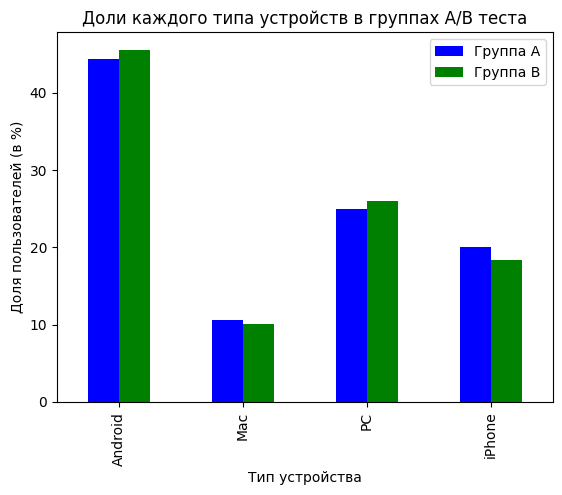

In [12]:
# Рассчитываем доли типов устройств в каждой группе
count_device_a = sessions_test_part[sessions_test_part['test_group'] == 'A'].groupby('device')['user_id'].nunique()
perc_device_a = (count_device_a / count_device_a.sum() * 100).round(2)

count_device_b = sessions_test_part[sessions_test_part['test_group'] == 'B'].groupby('device')['user_id'].nunique()
perc_device_b = (count_device_b / count_device_b.sum() * 100).round(2)

# Cтроим график
devices = pd.DataFrame({
    'Группа А': perc_device_a,
    'Группа В': perc_device_b})
devices.plot(kind='bar', color=['blue', 'green'])
plt.title('Доли каждого типа устройств в группах А/В теста')
plt.xlabel('Тип устройства')
plt.ylabel('Доля пользователей (в %)')
plt.legend()
plt.show()

Пользователи распределены практически равномерно. Разница в кол-во пользователей минимальна и незначительна.

### Равномерность распределения пользователей по регионам
Теперь убедимся, что пользователи равномерно распределены по регионам.

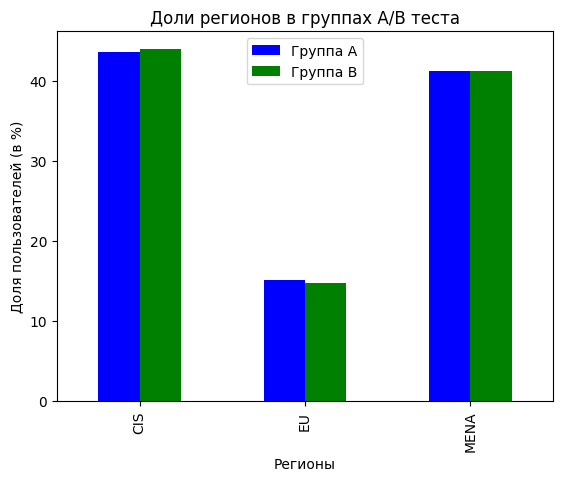

In [13]:
# Рассчитываем доли регионов в каждой группе теста
count_region_a = sessions_test_part[sessions_test_part['test_group'] == 'A'].groupby('region')['user_id'].nunique()
perc_region_a = (count_region_a / count_region_a.sum() * 100).round(2)

count_region_b = sessions_test_part[sessions_test_part['test_group'] == 'B'].groupby('region')['user_id'].nunique()
perc_region_b = (count_region_b / count_region_b.sum() * 100).round(2)

# Строим график
regions = pd.DataFrame({
    'Группа А': perc_region_a,
    'Группа В': perc_region_b})

regions.plot(kind='bar', color=['blue', 'green'])
plt.title('Доли регионов в группах А/В теста')
plt.xlabel('Регионы')
plt.ylabel('Доля пользователей (в %)')
plt.legend()
plt.show()

Пользователи распределены практически равномерно. Разница в кол-во пользователей минимальна и незначительна.

### Вывод после проверки A/B-теста

- Кол-во пользователей разнится незначительно (разница в процентном соотношении примерно 7%), поэтому данной разницей можно принебречь.
- Пересечений между группами не обнаруженно, соответственно обе выборки независимы.
- Распределения по устройствам и регионам также разнятся незначительно

По итогу проверок делаем вывод, что нарушений не наблюдается, можно проводить А/В-тест

## Проверка результатов A/B-теста

A/B-тест завершён, и у вас есть результаты за все дни проведения эксперимента. Необходимо убедиться в корректности теста и верно интерпретировать результаты.

### Получение результатов теста и подсчёт основной метрики
В датафрейме `sessions_test` создадим дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если просмотрено меньше.

In [14]:
sessions_test = pd.read_csv('/datasets/sessions_project_test.csv')

#Создаем столбец good_session через функцию
def is_good_session(row):
    if row['page_counter'] >= 4:
        return 1
    else:
        return 0

sessions_test['good_session'] = sessions_test.apply(is_good_session, axis=1)

### Формулировка нулевой и альтернативной гипотез. Определение целевой, прокси- и барьерных метрик


Перед тем как проводить А/B-тест, необходимо сформулировать нулевую и альтернативную гипотезы. Напомним изначальное условие: команда разработчиков рекомендательных систем создала новый алгоритм, который, по их мнению, будет показывать более интересный контент для каждого пользователя.

*Нулевая гипотеза:* Новый алгоритм не влияет на удовлетворенность пользователей контентом.  
*Альтернативная гипотеза:* Новый алгоритм повышает удовлетворенность пользователей контентом.

### Сравнение доли успешных первых сессий

Перейдем к анализу ключевой метрики — доле успешных первых сессий.

In [17]:
# Считаем доли
first_sessions_perc = sessions_test[sessions_test['session_number'] == 1].groupby('test_group')['good_session'].mean()

print(f'Доля успешных сессий в группе А: {first_sessions_perc["A"]}')
print(f'Доля успешных сессий в группе B: {first_sessions_perc["B"]}')

# Находим разницу долей
perc_diff = first_sessions_perc["B"] - first_sessions_perc["A"]
print(f'Разница долей: {perc_diff}')

Доля успешных сессий в группе А: 0.31572351932462733
Доля успешных сессий в группе B: 0.3146730669434354
Разница долей: -0.0010504523811919464


### Насколько статистически значимо изменение ключевой метрики

In [19]:
# Находим размеры выборок
n_a = sessions_test[(sessions_test['session_number'] == 1) & (sessions_test['test_group'] == 'A')].shape[0]
n_b = sessions_test[(sessions_test['session_number'] == 1) & (sessions_test['test_group'] == 'B')].shape[0]

# Находим кол-во успехов
m_a = int((first_sessions_perc['A'] / 100) * n_a)
m_b = int((first_sessions_perc['B'] / 100) * n_b)

alpha = 0.05

stat_ztest, p_value_ztest = proportions_ztest(
    [m_a, m_b],
    [n_a, n_b],
    alternative='smaller')

print(f'Зачение pvalue: {p_value_ztest}')

if p_value_ztest > alpha:
    print(f'Нулевая гипотеза верна. Отвергаем альтернативную гипотезу')
else:
    print(f'Нулевая гипотеза неверна. Алгоритм работает корректно. Подтверждаем альтернативную гипотезу')

Зачение pvalue: 0.49135587780064205
Нулевая гипотеза верна. Отвергаем альтернативную гипотезу


### Вывод по результатам A/B-эксперимента

Для првоедения эксперимента случайным образом были отобраны 82080 независимых пользователя (по 41040 в каждой группе). Рассматривалось влияние нового алгоритма на удовлетворение пользователей контентом. В качестве ключевой метрики было выбрано количество просмотренных страниц равное 4 или больше во время первой сессии пользователей. Длительность эксперимента - 9 дней.  
В результате проведения z-теста определено, что внедрение нового алгоритма рекомендаций **не повлияло на рост ключевой метрики**.
Значение pvalue больше уровня значимости, что указывает на то, что различие в долях успешных первых сессий между контрольной и тестовой группой **не является статистически значимым**.  
Таким образом, **алгоритм не рекомендован к внедрению в приложение**.